# Preprocessing

### Import Libraries


In [4]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler

## Load Data

In [5]:
df = pd.read_excel(r"Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Data Cleaning

In [6]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

## Feature Engineering

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

## RFM Creation

In [6]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

## Scaling

In [7]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

## Output Check

In [8]:
print(rfm.head())
print(rfm_scaled.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.358668
12347.0    -0.905340   0.354417  0.250966
12348.0    -0.175360  -0.035340 -0.028596
12349.0    -0.735345  -0.425097 -0.033012
12350.0     2.174578  -0.425097 -0.191347


# EDA


In [ ]:
import sys
!{sys.executable} -m pip install seaborn

# Data Understanding

We explore dataset shape and statistics.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# STYLE
sns.set(style="whitegrid")

# BASIC INFO
print("Shape:", rfm.shape)
print("\nSummary Statistics:\n", rfm.describe())



Shape: (4338, 3)

Summary Statistics:
            Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


# Distribution Analysis

We visualize the distribution of RFM features

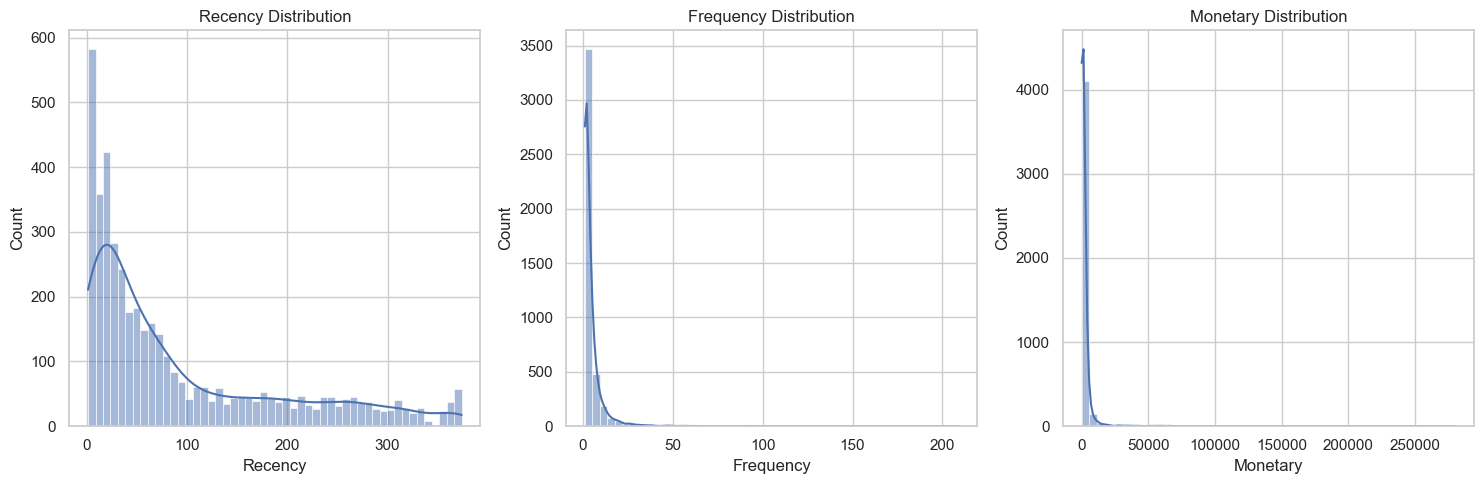

In [ ]:

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], bins=50, kde=True)
plt.title('Recency Distribution')

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], bins=50, kde=True)
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], bins=50, kde=True)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

# Outlier Detection

We detect extreme values in the dataset.

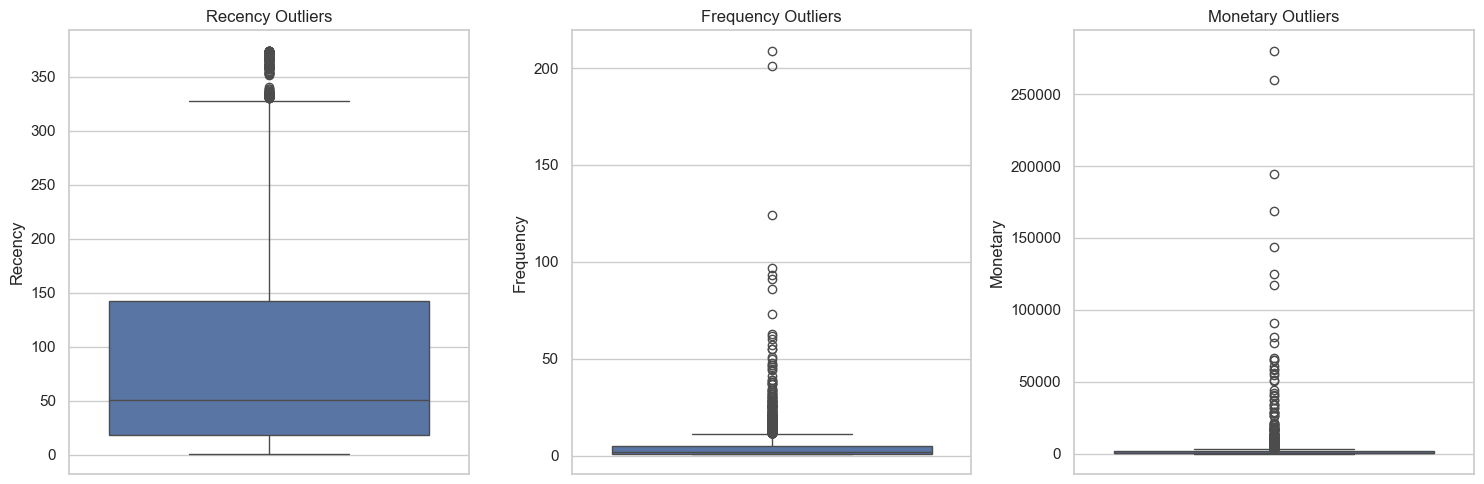

In [ ]:


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])
plt.title('Recency Outliers')

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])
plt.title('Frequency Outliers')

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary Outliers')

plt.tight_layout()
plt.show()

# Correlation Analysis

We analyze relationships between RFM features.

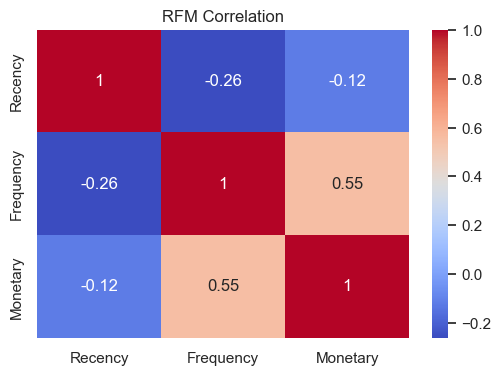

In [ ]:
# 3. CORRELATION HEATMAP

plt.figure(figsize=(6,4))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation')
plt.show()

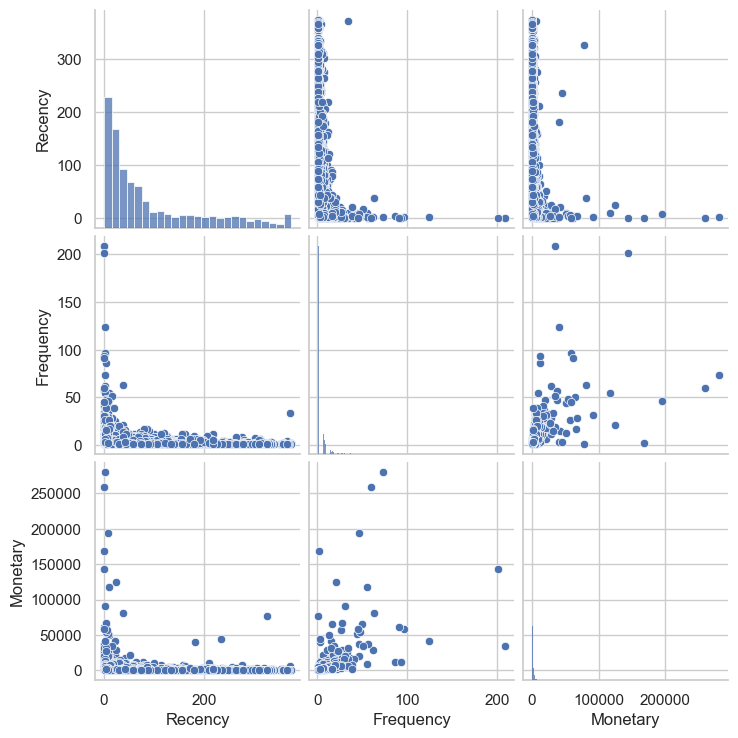

In [ ]:


sns.pairplot(rfm)
plt.show()


# Log Transformation

We apply log transformation to reduce skewness

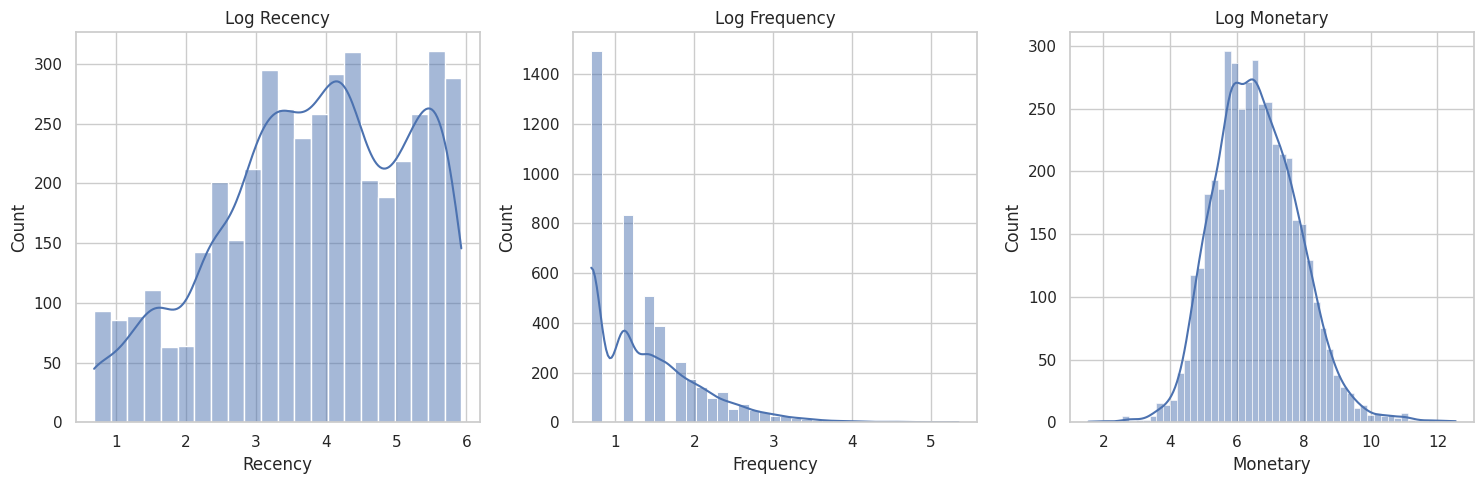

In [ ]:
# 5. LOG TRANSFORMATION (OPTIONAL BUT PRO LEVEL)

rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm_log['Recency'], kde=True)
plt.title('Log Recency')

plt.subplot(1,3,2)
sns.histplot(rfm_log['Frequency'], kde=True)
plt.title('Log Frequency')

plt.subplot(1,3,3)
sns.histplot(rfm_log['Monetary'], kde=True)
plt.title('Log Monetary')

plt.tight_layout()
plt.show()

# RFM Scoring

We assign scores (1–4) for Recency, Frequency, and Monetary.

In [ ]:

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score
CustomerID                                                                
12346.0         326          1  77183.60       1       1       4       114
12347.0           2          7   4310.00       4       4       4       444
12348.0          75          4   1797.24       2       3       4       234
12349.0          19          1   1757.55       3       1       4       314
12350.0         310          1    334.40       1       1       2       112


# Segment Distribution

We analyze distribution of customer segments.

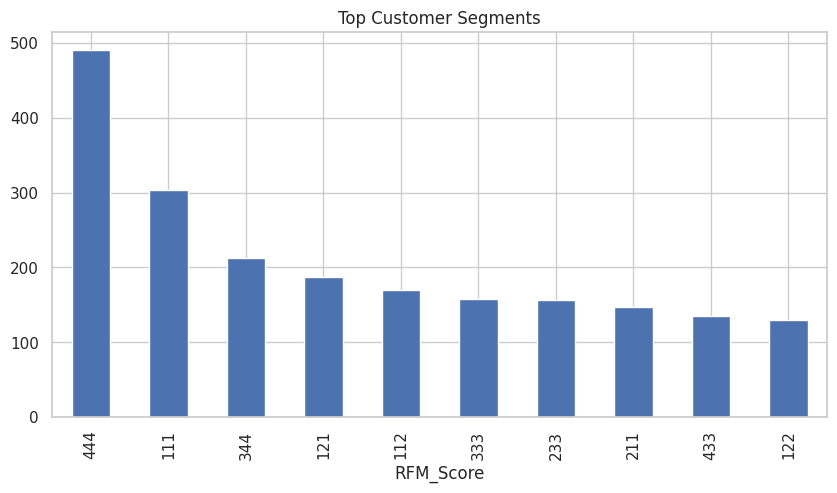

In [ ]:
# 7. SEGMENT DISTRIBUTION

plt.figure(figsize=(10,5))
rfm['RFM_Score'].value_counts().head(10).plot(kind='bar')
plt.title('Top Customer Segments')
plt.show()

In [ ]:
pip install openpyxl

# Customer Segmentation using KMeans

We applied KMeans clustering algorithm to segment customers into 3 groups based on their RFM behavior.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(rfm_scaled)


rfm['Cluster'] = kmeans.labels_

print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        1
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


# Assigning Cluster Labels

In [ ]:
print(rfm['Cluster'].value_counts())

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64


# Cluster Distribution

In [ ]:
cluster_summary = rfm.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         40.983906   4.852677    2012.111620
1        246.023788   1.582800     631.141410
2          7.142857  80.214286  122888.407143


# Dataset Summary

We analyze the full dataset statistics including clusters.

In [ ]:
print(rfm.describe())
print(rfm_scaled.describe())

           Recency    Frequency       Monetary      Cluster
count  4338.000000  4338.000000    4338.000000  4338.000000
mean     92.536422     4.272015    2054.266460     0.258414
std     100.014169     7.697998    8989.230441     0.445125
min       1.000000     1.000000       3.750000     0.000000
25%      18.000000     1.000000     307.415000     0.000000
50%      51.000000     2.000000     674.485000     0.000000
75%     142.000000     5.000000    1661.740000     1.000000
max     374.000000   209.000000  280206.020000     2.000000
            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean   2.702618e-17  1.801745e-17  1.801745e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.153401e-01 -4.250965e-01 -2.281344e-01
25%   -7.453445e-01 -4.250965e-01 -1.943495e-01
50%   -4.153533e-01 -2.951776e-01 -1.535104e-01
75%    4.946227e-01  9.457903e-02 -4.367134e-02
max    2.814561e+00  2.659803e+01  3.094634e+01


# Elbow Plot Analysis

The inertia decreases as the number of clusters increases.



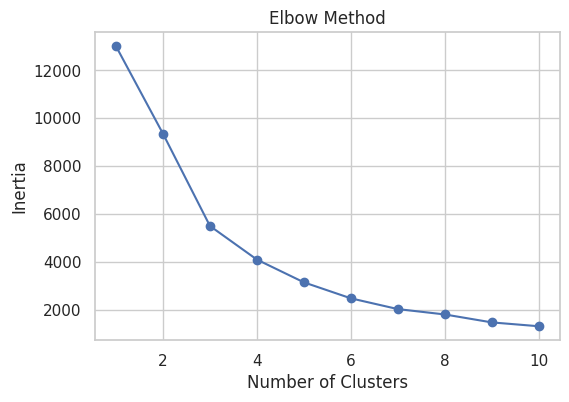

In [ ]:


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Silhouette Score Evaluation

We evaluated clustering quality using Silhouette Score for different K values.

In [ ]:


from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)

    print(f'K = {k}, Silhouette Score = {score}')

K = 2, Silhouette Score = 0.5603671809121974
K = 3, Silhouette Score = 0.5852924318247733
K = 4, Silhouette Score = 0.616212846765192
K = 5, Silhouette Score = 0.617115186725246
K = 6, Silhouette Score = 0.5982715957283189
K = 7, Silhouette Score = 0.51717221452567
K = 8, Silhouette Score = 0.49091567183009177
K = 9, Silhouette Score = 0.484017028247486


# Final KMeans Model

In [ ]:


kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
CustomerID                                                                   
12346.0         326          1  77183.60       1       1       4       114   
12347.0           2          7   4310.00       4       4       4       444   
12348.0          75          4   1797.24       2       3       4       234   
12349.0          19          1   1757.55       3       1       4       314   
12350.0         310          1    334.40       1       1       2       112   

            Cluster  
CustomerID           
12346.0           1  
12347.0           0  
12348.0           0  
12349.0           0  
12350.0           1  


# Cluster Visualization

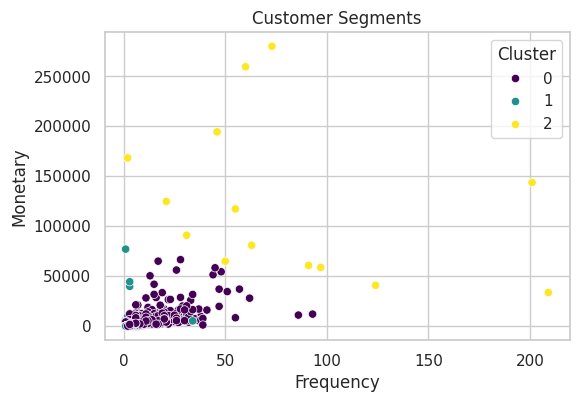

In [ ]:


import seaborn as sns

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='viridis'
)

plt.title('Customer Segments')
plt.show()

# Final KMeans Model & Technical Validation

#  Importing Required Libraries

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from scipy import stats

# Elbow Method (Optimal Number of Clusters)

We used the Elbow Method to determine the best number of clusters for KMeans


In [ ]:
k = 5

kmeans_final = KMeans(n_clusters=k, random_state=42)
clusters = kmeans_final.fit_predict(rfm_scaled)

rfm['Final_Cluster'] = clusters

# Model Evaluation (Silhouette Score)


In [ ]:
final_score = silhouette_score(rfm_scaled, clusters)
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.617115186725246


# Evaluation Before Outlier Removal


In [ ]:
kmeans_before = KMeans(n_clusters=5, random_state=42)
clusters_before = kmeans_before.fit_predict(rfm_scaled)

score_before = silhouette_score(rfm_scaled, clusters_before)
print("Before Cleaning:", score_before)

Before Cleaning: 0.617115186725246


# Outlier Detection and Removal


In [ ]:
Q1 = rfm_scaled.quantile(0.25)
Q3 = rfm_scaled.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm_clean = rfm_scaled[~((rfm_scaled < lower_bound) | (rfm_scaled > upper_bound)).any(axis=1)]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)

# Z-Score Outlier Detection

In [ ]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(rfm_scaled))

rfm_clean_scaled = rfm_scaled[(z_scores < 3).all(axis=1)]

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(rfm_clean_scaled)

# Evaluation After Outlier Removal


In [ ]:
from sklearn.metrics import silhouette_score

score_after = silhouette_score(rfm_clean_scaled, labels)
print("Silhouette Score After Outlier Removal:", score_after)

Silhouette Score After Outlier Removal: 0.37044231548662854


In [ ]:
print("Inertia After Outlier Removal:", kmeans.inertia_)

Inertia After Outlier Removal: 1999.223823988206


In [ ]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} customers")

Cluster 0: 476 customers
Cluster 1: 573 customers
Cluster 2: 808 customers
Cluster 3: 499 customers
Cluster 4: 1241 customers


In [ ]:
print("Before Outlier Removal:", score_before)
print("After Outlier Removal:", score_after)

Before Outlier Removal: 0.617115186725246
After Outlier Removal: 0.37044231548662854


# Performance Comparison (Before vs After)


# Silhouette Score After Cleaning

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Before (on original scaled data)
kmeans_before = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_before = kmeans_before.fit_predict(rfm_scaled)

score_before = silhouette_score(rfm_scaled, labels_before)

# After (on cleaned scaled data)
kmeans_after = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_after = kmeans_after.fit_predict(rfm_clean_scaled)

score_after = silhouette_score(rfm_clean_scaled, labels_after)

print("Before Silhouette Score:", score_before)
print("After Silhouette Score:", score_after)

Before Silhouette Score: 0.40040278916922234
After Silhouette Score: 0.37044231548662854


# Before vs After Inertia Comparison

In [ ]:
print("Before Inertia:", kmeans_before.inertia_)
print("After Inertia:", kmeans_after.inertia_)

Before Inertia: 2321.4511996090127
After Inertia: 1999.2238239882058


# Performance Comparison Table

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Before Outliers Removal", "After Outliers Removal"],
    "Silhouette Score": [score_before, score_after]
})

comparison

,Model,Silhouette Score
0,Before Outliers Removal,0.400403
1,After Outliers Removal,0.370442


# Model Comparison (Before vs After)

We visualize Silhouette Score comparison.

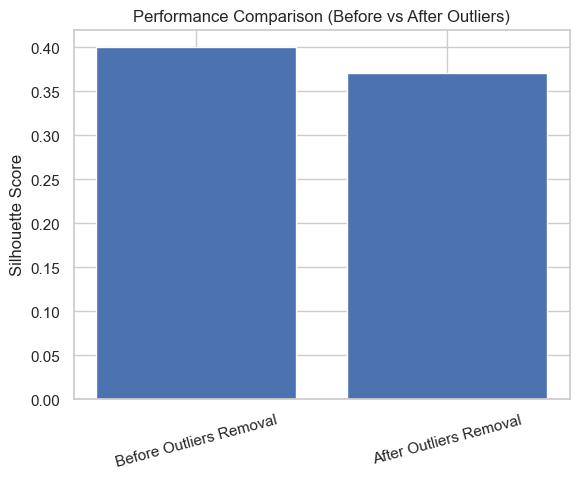

In [ ]:
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["Silhouette Score"])
plt.title("Performance Comparison (Before vs After Outliers)")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=15)
plt.show()

# Cluster Analysis


In [ ]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

,Recency,Frequency,Monetary,Final_Cluster
Cluster,,,,
0,40.983906,4.852677,2012.111620,0.182606
1,246.023788,1.582800,631.141410,0.983532
2,7.142857,80.214286,122888.407143,3.071429


In [ ]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

# Final Cluster Visualization

We visualize clusters in 2D space.

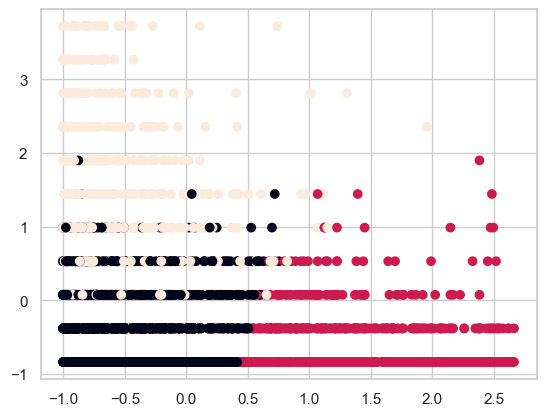

In [ ]:

X = rfm_scaled

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters
)
plt.show()

# Association Rule Mining (Market Basket Analysis)


In [8]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'] \
           .sum().unstack().fillna(0)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print(basket.head())

C:\Users\alimo\AppData\Local\Temp\ipykernel_11812\3248534385.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                         

In [9]:
print(basket.stack().value_counts())

0    71460826
1      387738
Name: count, dtype: int64
